# 12. Reentrenamiento Refinado de Last Visible Thoracolumbar - Colab

Este notebook implementa la siguiente iteracion priorizada por los notebooks
`10` y `11`: reentrenar el estimador de ultima vertebra visible usando
muestreo refinado y enfasis en casos dificiles.

## Por que existe este notebook

La evidencia previa mostro que:

- la mejor variante actual sigue siendo `last_visible_pred_clip`
- el problema dominante es la sobreprediccion hacia vertebras mas bajas
- los casos parciales y de escoliosis siguen siendo el cuello de botella
- el notebook `10` ya identifico pesos refinados y tipos de muestra prioritarios

## Idea de esta version refinada

Mantenemos la misma arquitectura general del `07`, pero cambiamos la forma de
entrenarla:

1. usamos `WeightedRandomSampler` con pesos derivados del notebook `10`
2. damos mas enfasis a muestras parciales, raras y de escoliosis
3. hacemos `warm start` desde el mejor checkpoint actual
4. agregamos una penalizacion adicional a la sobreprediccion

## Objetivo del notebook

1. reutilizar el pipeline que ya funciona
2. reentrenar `last_visible_idx` con sampling refinado
3. comparar el resultado refinado contra el baseline anterior
4. medir si cerramos parte del gap hacia el `oracle_clip`

## 0. Preparacion de Colab

Ajusta `PROJECT_ROOT` si en tu Google Drive la carpeta tiene otro nombre o ruta.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/DataRadriografias")
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"No existe la carpeta: {PROJECT_ROOT}")

os.chdir(PROJECT_ROOT)
print("Working directory:", Path.cwd())

Mounted at /content/drive
Working directory: /content/drive/MyDrive/DataRadriografias


## 1. Librerias y configuracion general

Esta etapa reutiliza:

- modelo binario ya entrenado
- mejor modelo multiclase `partial`

y agrega una etapa de **reentrenamiento refinado** del estimador `last_visible`.

In [2]:
from __future__ import annotations

import copy
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT = Path.cwd()
DATASET_ROOT = ROOT / 'data' / 'Scoliosis_Dataset'

def resolve_existing(*relative_candidates: str) -> Path:
    search_roots = [ROOT, ROOT / 'reports']
    for base in search_roots:
        for rel in relative_candidates:
            candidate = base / rel
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f'No se encontro ninguno de estos archivos: {relative_candidates}')


def resolve_optional(*relative_candidates: str) -> Path | None:
    search_roots = [ROOT, ROOT / 'reports']
    for base in search_roots:
        for rel in relative_candidates:
            candidate = base / rel
            if candidate.exists():
                return candidate
    return None


INDEX_PATH = resolve_existing('indice_dataset.csv')
DICT_PATH = resolve_existing('diccionario_etiquetas_T1_T12_L1_L5.json')
MANIFEST_PATH = resolve_existing('analysis_outputs/training_manifest_thoracolumbar.csv')
BINARY_GROUP_MAP_PATH = resolve_existing('analysis_outputs/training_runs_binary_thoracolumbar/binary_spine_group_partition_map.csv')
BINARY_MODEL_PATH = resolve_existing('models/binary_spine_thoracolumbar_best.pt')
MULTICLASS_MODEL_PATH = resolve_existing('models/thoracolumbar_partial_cascade_explained_best.pt')
BASELINE_MODEL_PATH = resolve_optional('models/last_visible_estimator_thoracolumbar_best.pt')
BASELINE_SUMMARY_PATH = resolve_optional(
    'analysis_outputs/last_visible_estimator_thoracolumbar_explained/last_visible_experiment_summary.csv'
)
BASELINE_PER_SAMPLE_PATH = resolve_optional(
    'analysis_outputs/last_visible_estimator_thoracolumbar_explained/last_visible_per_sample_compare.csv'
)
REFINED_SAMPLING_PATH = resolve_optional(
    'analysis_outputs/hard_case_mining_thoracolumbar_explained/train_sampling_weights_last_visible.csv'
)
HARD_CASE_PATH = resolve_optional(
    'analysis_outputs/hard_case_mining_thoracolumbar_explained/hard_cases_last_visible_test.csv'
)
PREV_RANGE_TEST_PATH = resolve_optional('analysis_outputs/visible_range_estimator_thoracolumbar_explained/visible_range_test_predictions.csv')
OUTPUT_DIR = ROOT / 'analysis_outputs' / 'last_visible_estimator_thoracolumbar_refined_explained'
MODEL_DIR = ROOT / 'models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [
    INDEX_PATH, DICT_PATH, MANIFEST_PATH, BINARY_GROUP_MAP_PATH,
    BINARY_MODEL_PATH, MULTICLASS_MODEL_PATH,
]
for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f'No existe archivo requerido: {path}')

def resolve_dataset_path(rel: str) -> str:
    rel_path = Path(str(rel).replace(chr(92), '/'))
    if rel_path.is_absolute():
        return str(rel_path)
    candidates = [
        ROOT / rel_path,
        DATASET_ROOT / rel_path,
    ]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate.resolve())
    return str((DATASET_ROOT / rel_path).resolve())

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'
USE_AMP = DEVICE.type == 'cuda'

TARGET_SUBSET = 'partial'
IMG_SIZE_BINARY = (512, 256)
IMG_SIZE_MULTICLASS = (640, 320)
IMG_SIZE_LAST = (384, 192)
BINARY_THRESHOLD = 0.50
ROI_PAD_X = 28
ROI_PAD_Y = 44
MIN_FOREGROUND_PIXELS = 24
IGNORE_INDEX = 255

LAST_BATCH_SIZE = 8
LAST_NUM_WORKERS = 2
LAST_EPOCHS = 24
LAST_LR = 4e-4
LAST_WEIGHT_DECAY = 1e-4
LAST_PATIENCE = 8
LAST_DROPOUT = 0.25
LAST_LABEL_SMOOTHING = 0.03
WARM_START_FROM_BASELINE = True
SAMPLER_WEIGHT_CLIP_MIN = 0.75
SAMPLER_WEIGHT_CLIP_MAX = 12.0
CURRICULUM_BOOST = 1.20
OVERPREDICTION_PENALTY = 0.35
UNDERPREDICTION_PENALTY = 0.10

PRESENCE_THRESHOLD_PIXELS = 40
PROFILE_BINS = 24
N_VIS_SAMPLES = 8

print('DEVICE:', DEVICE)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('BASELINE_MODEL_PATH:', BASELINE_MODEL_PATH)
print('BASELINE_SUMMARY_PATH:', BASELINE_SUMMARY_PATH)
print('REFINED_SAMPLING_PATH:', REFINED_SAMPLING_PATH)
print('HARD_CASE_PATH:', HARD_CASE_PATH)

DEVICE: cuda
OUTPUT_DIR: /content/drive/MyDrive/DataRadriografias/analysis_outputs/last_visible_estimator_thoracolumbar_refined_explained
BASELINE_MODEL_PATH: /content/drive/MyDrive/DataRadriografias/models/last_visible_estimator_thoracolumbar_best.pt
BASELINE_SUMMARY_PATH: /content/drive/MyDrive/DataRadriografias/analysis_outputs/last_visible_estimator_thoracolumbar_explained/last_visible_experiment_summary.csv
REFINED_SAMPLING_PATH: /content/drive/MyDrive/DataRadriografias/analysis_outputs/hard_case_mining_thoracolumbar_explained/train_sampling_weights_last_visible.csv
HARD_CASE_PATH: /content/drive/MyDrive/DataRadriografias/analysis_outputs/hard_case_mining_thoracolumbar_explained/hard_cases_last_visible_test.csv


## 2. Metadata y target supervisado

Construimos el target `last_visible_idx` a partir de las mascaras reales.
Tambien mantenemos `first_visible_idx` como referencia para clipping y analisis.

In [3]:
index_df_raw = pd.read_csv(INDEX_PATH)
manifest_df = pd.read_csv(MANIFEST_PATH)
group_map_df = pd.read_csv(BINARY_GROUP_MAP_PATH)
with open(DICT_PATH, 'r', encoding='utf-8') as f:
    labels_dict = json.load(f)

index_col_map = {
    'grupo': 'split',
    'imagen': 'image',
    'id_paciente': 'patient_id',
    'ruta_radiografia': 'radiograph_path',
    'ruta_mascara_binaria': 'label_binary_path',
    'ruta_mascara_multiclase_id_png': 'multiclass_id_png',
}
index_df = index_df_raw.rename(columns=index_col_map).copy()

final_multiclass_map = {int(k): v for k, v in labels_dict['mascara_multiclase_id_png'].items()}
class_names = [final_multiclass_map[i] for i in range(len(final_multiclass_map))]
num_classes = len(class_names)
canonical_labels = [f'T{i}' for i in range(1, 13)] + [f'L{i}' for i in range(1, 6)]
label_to_class_id = {label: idx for idx, label in enumerate(class_names)}
valid_multiclass_ids = set(range(num_classes))

join_cols = ['split', 'image', 'patient_id', 'radiograph_path']
dataset_subset = index_df[join_cols + ['label_binary_path', 'multiclass_id_png']].copy()
table = manifest_df.merge(dataset_subset, on=join_cols, how='left', suffixes=('', '_idx'))
table['multiclass_mask_path'] = table['mask_path'].fillna(table['multiclass_id_png'])
table['radiograph_path_abs'] = table['radiograph_path'].apply(resolve_dataset_path)
table['binary_mask_path_abs'] = table['label_binary_path'].apply(resolve_dataset_path)
table['multiclass_mask_path_abs'] = table['multiclass_mask_path'].apply(resolve_dataset_path)

for col in ['usable_for_thoracolumbar_core', 'usable_for_thoracolumbar_partial', 'needs_annotation_review']:
    if col in table.columns:
        table[col] = table[col].map(
            lambda x: x if isinstance(x, bool) else str(x).strip().lower() == 'true'
        )

group_partition_map = group_map_df.drop_duplicates().set_index('group_id_for_split')['partition'].to_dict()
table['partition'] = table['group_id_for_split'].map(group_partition_map)


def extract_visible_range_from_mask(path: str) -> tuple[int | None, int | None, list[str]]:
    raw = np.array(Image.open(path), dtype=np.int32)
    ids = sorted(int(x) for x in np.unique(raw) if int(x) in valid_multiclass_ids and int(x) > 0)
    labels = [class_names[class_id] for class_id in ids if class_names[class_id] in canonical_labels]
    if not labels:
        return None, None, []
    first_idx = canonical_labels.index(labels[0])
    last_idx = canonical_labels.index(labels[-1])
    return first_idx, last_idx, labels


subset_flag = 'usable_for_thoracolumbar_core' if TARGET_SUBSET == 'core' else 'usable_for_thoracolumbar_partial'
work_df = table.loc[
    table[subset_flag] & ~table['needs_annotation_review']
].copy().reset_index(drop=True)

first_last = work_df['multiclass_mask_path_abs'].apply(extract_visible_range_from_mask)
work_df['first_visible_idx'] = [item[0] for item in first_last]
work_df['last_visible_idx'] = [item[1] for item in first_last]
work_df['visible_labels_gt'] = [', '.join(item[2]) for item in first_last]
work_df = work_df.loc[
    work_df['first_visible_idx'].notna() & work_df['last_visible_idx'].notna()
].copy().reset_index(drop=True)
work_df['first_visible_idx'] = work_df['first_visible_idx'].astype(int)
work_df['last_visible_idx'] = work_df['last_visible_idx'].astype(int)
work_df['first_visible_label'] = work_df['first_visible_idx'].map(lambda idx: canonical_labels[int(idx)])
work_df['last_visible_label'] = work_df['last_visible_idx'].map(lambda idx: canonical_labels[int(idx)])

print('Muestras para last-visible estimator:', len(work_df))
display(work_df.groupby('partition').size().rename('images').reset_index())
display(work_df[['partition', 'split', 'image', 'first_visible_label', 'last_visible_label']].head(10))

Muestras para last-visible estimator: 224


,partition,images
0,test,45
1,train,143
2,val,36


,partition,split,image,first_visible_label,last_visible_label
0,train,Normal,N_1.jpg,T1,L5
1,train,Normal,N_2.jpg,T1,L5
2,val,Normal,N_3.jpg,T1,L5
3,test,Normal,N_4.jpg,T1,L5
4,train,Normal,N_5.jpg,T1,L5
5,test,Normal,N_6.jpg,T1,L5
6,train,Normal,N_7.jpg,T1,L5
7,test,Normal,N_8.jpg,T1,L5
8,train,Normal,N_9.jpg,T1,L5
9,train,Normal,N_10.jpg,T1,L5


## 3. Distribucion del target `last_visible_idx`

Este paso es importante porque aqui realmente esta la dificultad del problema.

In [4]:
last_dist_df = (
    work_df.groupby(['partition', 'last_visible_label'])
    .size()
    .rename('images')
    .reset_index()
    .sort_values(['partition', 'images'], ascending=[True, False])
)
display(last_dist_df.head(30))

,partition,last_visible_label,images
4,test,L5,15
3,test,L4,6
2,test,L3,5
7,test,T12,5
1,test,L2,3
5,test,T10,3
6,test,T11,2
9,test,T7,2
0,test,L1,1
8,test,T6,1


## 4. Utilidades de imagen, ROI y modelos base

Reutilizamos:

- modelo binario para localizar la ROI
- modelo multiclase como fuente de mascara y de features anatomicas

In [5]:
def read_gray(path: str) -> np.ndarray:
    return np.array(Image.open(path).convert('L'))


def resize_image(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr).resize((size[1], size[0]), resample=Image.BILINEAR))


def resize_mask(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr.astype(np.uint8)).resize((size[1], size[0]), resample=Image.NEAREST))


def build_binary_mask(path: str, size: tuple[int, int] | None = None) -> np.ndarray:
    mask = read_gray(path)
    mask = (mask >= 127).astype(np.uint8)
    if size is not None:
        mask = resize_mask(mask, size)
    return mask


def build_multiclass_mask(path: str, size: tuple[int, int] | None = None) -> np.ndarray:
    raw = np.array(Image.open(path), dtype=np.int32)
    out = np.zeros_like(raw, dtype=np.uint8)
    valid_mask = np.isin(raw, list(valid_multiclass_ids))
    out[~valid_mask] = IGNORE_INDEX
    out[valid_mask] = raw[valid_mask].astype(np.uint8)
    if size is not None:
        out = resize_mask(out, size)
    return out


def bbox_from_mask(mask: np.ndarray, min_foreground_pixels: int = 24) -> tuple[int, int, int, int] | None:
    ys, xs = np.where(mask > 0)
    if len(xs) < min_foreground_pixels:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1


def clamp_bbox(bbox: tuple[int, int, int, int], image_shape: tuple[int, int]) -> tuple[int, int, int, int]:
    h, w = image_shape
    x0, y0, x1, y1 = bbox
    x0 = max(0, min(x0, w - 1))
    y0 = max(0, min(y0, h - 1))
    x1 = max(x0 + 1, min(x1, w))
    y1 = max(y0 + 1, min(y1, h))
    return x0, y0, x1, y1


def expand_bbox(bbox: tuple[int, int, int, int], image_shape: tuple[int, int], pad_x: int = 28, pad_y: int = 44) -> tuple[int, int, int, int]:
    x0, y0, x1, y1 = bbox
    return clamp_bbox((x0 - pad_x, y0 - pad_y, x1 + pad_x, y1 + pad_y), image_shape)


def scale_bbox(bbox: tuple[int, int, int, int], src_shape: tuple[int, int], dst_shape: tuple[int, int]) -> tuple[int, int, int, int]:
    src_h, src_w = src_shape
    dst_h, dst_w = dst_shape
    x0, y0, x1, y1 = bbox
    sx = dst_w / src_w
    sy = dst_h / src_h
    scaled = (int(round(x0 * sx)), int(round(y0 * sy)), int(round(x1 * sx)), int(round(y1 * sy)))
    return clamp_bbox(scaled, dst_shape)


def crop_array(arr: np.ndarray, bbox: tuple[int, int, int, int]) -> np.ndarray:
    x0, y0, x1, y1 = bbox
    return arr[y0:y1, x0:x1]


def normalize_image(image_2d: np.ndarray) -> np.ndarray:
    mean = float(image_2d.mean())
    std = float(image_2d.std())
    if std < 1e-6:
        return image_2d - mean
    return (image_2d - mean) / std


def build_coordinate_channels(height: int, width: int) -> np.ndarray:
    y_coords = np.linspace(0.0, 1.0, height, dtype=np.float32)[:, None]
    x_coords = np.linspace(0.0, 1.0, width, dtype=np.float32)[None, :]
    y_map = np.repeat(y_coords, width, axis=1)
    x_map = np.repeat(x_coords, height, axis=0)
    return np.stack([y_map, x_map], axis=0)


class DoubleConvBinary(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class BinaryUNetSmall(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, base: int = 32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = DoubleConvBinary(in_channels, base)
        self.e2 = DoubleConvBinary(base, base * 2)
        self.e3 = DoubleConvBinary(base * 2, base * 4)
        self.e4 = DoubleConvBinary(base * 4, base * 8)
        self.b = DoubleConvBinary(base * 8, base * 16)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.d4 = DoubleConvBinary(base * 16, base * 8)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.d3 = DoubleConvBinary(base * 8, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.d2 = DoubleConvBinary(base * 4, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.d1 = DoubleConvBinary(base * 2, base)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b = self.b(self.pool(e4))
        d4 = self.d4(torch.cat([self.u4(b), e4], dim=1))
        d3 = self.d3(torch.cat([self.u3(d4), e3], dim=1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], dim=1))
        return self.head(d1)


class DoubleConv(nn.Module):
    def __init__(self, c_in: int, c_out: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UNetEnhanced(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, base: int = 48, dropout: float = 0.10):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = DoubleConv(in_channels, base, dropout=0.0)
        self.e2 = DoubleConv(base, base * 2, dropout=0.0)
        self.e3 = DoubleConv(base * 2, base * 4, dropout=0.0)
        self.e4 = DoubleConv(base * 4, base * 8, dropout=dropout * 0.5)
        self.b = DoubleConv(base * 8, base * 16, dropout=dropout)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.d4 = DoubleConv(base * 16, base * 8, dropout=dropout * 0.5)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.d3 = DoubleConv(base * 8, base * 4, dropout=0.0)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.d2 = DoubleConv(base * 4, base * 2, dropout=0.0)
        self.u1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.d1 = DoubleConv(base * 2, base, dropout=0.0)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b = self.b(self.pool(e4))
        d4 = self.d4(torch.cat([self.u4(b), e4], dim=1))
        d3 = self.d3(torch.cat([self.u3(d4), e3], dim=1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], dim=1))
        return self.head(d1)

## 5. Construccion de ROI e inferencia multiclase auxiliar

Aqui generamos para cada muestra:

- ROI espinal
- prediccion multiclase cruda
- features anatómicas derivadas de esa prediccion

Esta parte es importante porque el nuevo modelo no aprende solo de la imagen, sino
tambien de las pistas estructurales del segmentador actual.

In [6]:
binary_model = BinaryUNetSmall(in_channels=1, out_channels=1).to(DEVICE)
binary_model.load_state_dict(torch.load(BINARY_MODEL_PATH, map_location=DEVICE))
binary_model.eval()

multiclass_model = UNetEnhanced(in_channels=3, out_channels=num_classes, base=48, dropout=0.10).to(DEVICE)
multiclass_model.load_state_dict(torch.load(MULTICLASS_MODEL_PATH, map_location=DEVICE))
multiclass_model.eval()


def predict_binary_bbox_from_image(image_raw: np.ndarray) -> tuple[int, int, int, int] | None:
    image_resized = resize_image(image_raw, IMG_SIZE_BINARY).astype(np.float32) / 255.0
    image_tensor = torch.tensor(image_resized[None, None, ...], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        logits = binary_model(image_tensor)
        pred_mask_small = (torch.sigmoid(logits)[0, 0].detach().cpu().numpy() >= BINARY_THRESHOLD).astype(np.uint8)
    return bbox_from_mask(pred_mask_small, min_foreground_pixels=MIN_FOREGROUND_PIXELS)


def infer_multiclass_on_bbox(image_raw: np.ndarray, bbox: tuple[int, int, int, int]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    image_crop = crop_array(image_raw, bbox)
    image_crop = resize_image(image_crop, IMG_SIZE_MULTICLASS).astype(np.float32) / 255.0
    image_crop = normalize_image(image_crop)
    coords = build_coordinate_channels(IMG_SIZE_MULTICLASS[0], IMG_SIZE_MULTICLASS[1])
    image_channels = np.concatenate([np.expand_dims(image_crop, axis=0), coords], axis=0)
    image_tensor = torch.tensor(image_channels[None, ...], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        logits = multiclass_model(image_tensor)
        prob_map = torch.softmax(logits, dim=1)[0].detach().cpu().numpy().astype(np.float32)
        pred_mask = torch.argmax(logits, dim=1)[0].detach().cpu().numpy().astype(np.int64)
    return image_crop, pred_mask, prob_map


def extract_aux_features_from_pred_mask(pred_mask: np.ndarray, prob_map: np.ndarray) -> np.ndarray:
    h, w = pred_mask.shape
    fg_mask = (pred_mask > 0).astype(np.float32)
    total_fg = float(fg_mask.sum()) + 1e-6

    presence = []
    area_ratio = []
    centroid_y = []
    y_min_norm = []
    y_max_norm = []
    height_span_norm = []
    mean_confidence = []
    for label in canonical_labels:
        class_id = label_to_class_id[label]
        class_mask = pred_mask == class_id
        area = float(class_mask.sum())
        presence.append(1.0 if area >= PRESENCE_THRESHOLD_PIXELS else 0.0)
        area_ratio.append(area / total_fg)
        if area > 0:
            ys, _ = np.where(class_mask)
            centroid_y.append(float(np.mean(ys) / max(h - 1, 1)))
            y_min_norm.append(float(np.min(ys) / max(h - 1, 1)))
            y_max_norm.append(float(np.max(ys) / max(h - 1, 1)))
            height_span_norm.append(float((np.max(ys) - np.min(ys) + 1) / max(h, 1)))
            mean_confidence.append(float(prob_map[class_id][class_mask].mean()))
        else:
            centroid_y.append(0.0)
            y_min_norm.append(0.0)
            y_max_norm.append(0.0)
            height_span_norm.append(0.0)
            mean_confidence.append(0.0)

    pred_present_indices = [i for i, p in enumerate(presence) if p > 0.5]
    min_present_idx = float(min(pred_present_indices)) if pred_present_indices else 0.0
    max_present_idx = float(max(pred_present_indices)) if pred_present_indices else 0.0
    num_present = float(len(pred_present_indices))

    row_profile = fg_mask.sum(axis=1).astype(np.float32)
    if row_profile.max() > 0:
        row_profile = row_profile / row_profile.max()
    binned_profile = np.array_split(row_profile, PROFILE_BINS)
    profile_features = [float(chunk.mean()) for chunk in binned_profile]

    feature_vector = np.array(
        presence
        + area_ratio
        + centroid_y
        + y_min_norm
        + y_max_norm
        + height_span_norm
        + mean_confidence
        + [
            min_present_idx / (len(canonical_labels) - 1),
            max_present_idx / (len(canonical_labels) - 1),
            num_present / len(canonical_labels),
        ]
        + profile_features,
        dtype=np.float32,
    )
    return feature_vector


prep_rows = []
image_crop_lookup = {}
raw_pred_lookup_all = {}
aux_feature_lookup_all = {}
target_lookup_all = {}

for _, row in work_df.iterrows():
    image_raw = read_gray(row['radiograph_path_abs'])
    image_shape = image_raw.shape

    if row['partition'] == 'train':
        gt_binary = build_binary_mask(row['binary_mask_path_abs'], size=None)
        bbox = bbox_from_mask(gt_binary, min_foreground_pixels=MIN_FOREGROUND_PIXELS)
        roi_source = 'gt_binary'
    else:
        bbox_small = predict_binary_bbox_from_image(image_raw)
        bbox = scale_bbox(bbox_small, src_shape=IMG_SIZE_BINARY, dst_shape=image_shape) if bbox_small is not None else None
        roi_source = 'pred_binary'

    if bbox is None:
        x0, y0, x1, y1 = 0, 0, image_shape[1], image_shape[0]
        roi_source = f'{roi_source}_fallback_full_image'
    else:
        x0, y0, x1, y1 = expand_bbox(bbox, image_shape=image_shape, pad_x=ROI_PAD_X, pad_y=ROI_PAD_Y)

    bbox_final = (int(x0), int(y0), int(x1), int(y1))
    image_crop_2d, raw_pred_mask, raw_prob_map = infer_multiclass_on_bbox(image_raw, bbox_final)
    aux_features = extract_aux_features_from_pred_mask(raw_pred_mask, raw_prob_map)

    target_full = build_multiclass_mask(row['multiclass_mask_path_abs'], size=None)
    target_crop = crop_array(target_full, bbox_final)
    target_crop = resize_mask(target_crop, IMG_SIZE_MULTICLASS).astype(np.int64)

    prep_rows.append({
        'unique_sample_id': row['unique_sample_id'],
        'partition': row['partition'],
        'split': row['split'],
        'image': row['image'],
        'num_visible_target_vertebrae': int(row['num_visible_target_vertebrae']),
        'total_internal_missing_count': int(row.get('total_internal_missing_count', 0) or 0),
        'radiograph_path_abs': row['radiograph_path_abs'],
        'multiclass_mask_path_abs': row['multiclass_mask_path_abs'],
        'first_visible_idx': int(row['first_visible_idx']),
        'last_visible_idx': int(row['last_visible_idx']),
        'first_visible_label': row['first_visible_label'],
        'last_visible_label': row['last_visible_label'],
        'bbox_x0': bbox_final[0],
        'bbox_y0': bbox_final[1],
        'bbox_x1': bbox_final[2],
        'bbox_y1': bbox_final[3],
        'roi_source': roi_source,
    })

    image_crop_lookup[row['unique_sample_id']] = image_crop_2d
    raw_pred_lookup_all[row['unique_sample_id']] = raw_pred_mask
    aux_feature_lookup_all[row['unique_sample_id']] = aux_features
    target_lookup_all[row['unique_sample_id']] = target_crop

prep_df = pd.DataFrame(prep_rows)
aux_feature_matrix = np.stack([aux_feature_lookup_all[sid] for sid in prep_df['unique_sample_id']], axis=0)
aux_feature_dim = int(aux_feature_matrix.shape[1])

print('prep_df:', prep_df.shape)
print('aux_feature_dim:', aux_feature_dim)
display(prep_df.groupby(['partition', 'roi_source']).size().rename('images').reset_index())

prep_df: (224, 17)
aux_feature_dim: 146


,partition,roi_source,images
0,test,pred_binary,45
1,train,gt_binary,143
2,val,pred_binary,36


## 6. Dataset fusionado, sampler refinado y arquitectura

El modelo combina:

- encoder CNN sobre la ROI
- MLP sobre features anatomicas auxiliares
- fusion final para clasificar `last_visible_idx`

En esta nueva version agregamos un `WeightedRandomSampler` para aumentar la
frecuencia de casos raros y anatomias mas dificiles sin contaminar test.

In [7]:
partition_to_indices = {
    part: prep_df.index[prep_df['partition'] == part].to_numpy()
    for part in ['train', 'val', 'test']
}

train_aux_mean = aux_feature_matrix[partition_to_indices['train']].mean(axis=0)
train_aux_std = aux_feature_matrix[partition_to_indices['train']].std(axis=0)
train_aux_std = np.where(train_aux_std < 1e-6, 1.0, train_aux_std)


class LastVisibleDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, aux_features: np.ndarray, aux_mean: np.ndarray, aux_std: np.ndarray):
        self.frame = frame.reset_index(drop=True).copy()
        self.aux_features = aux_features
        self.aux_mean = aux_mean.astype(np.float32)
        self.aux_std = aux_std.astype(np.float32)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int) -> dict:
        row = self.frame.iloc[idx]
        sample_id = row['unique_sample_id']
        image_crop = image_crop_lookup[sample_id]
        image_small = resize_image((image_crop * 255.0).astype(np.uint8), IMG_SIZE_LAST).astype(np.float32) / 255.0
        image_small = normalize_image(image_small)
        coords = build_coordinate_channels(IMG_SIZE_LAST[0], IMG_SIZE_LAST[1])
        image_tensor = np.concatenate([np.expand_dims(image_small, axis=0), coords], axis=0)

        aux = self.aux_features[int(row['row_idx'])]
        aux = ((aux - self.aux_mean) / self.aux_std).astype(np.float32)
        return {
            'image': torch.tensor(image_tensor, dtype=torch.float32),
            'aux': torch.tensor(aux, dtype=torch.float32),
            'last_idx': torch.tensor(int(row['last_visible_idx']), dtype=torch.long),
            'first_idx': torch.tensor(int(row['first_visible_idx']), dtype=torch.long),
            'sample_id': sample_id,
        }


class ConvBlock(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class LastVisibleEstimator(nn.Module):
    def __init__(self, aux_dim: int, num_labels: int = 17, dropout: float = 0.25):
        super().__init__()
        self.image_encoder = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.image_pool = nn.AdaptiveAvgPool2d(1)
        self.image_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 192),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.aux_head = nn.Sequential(
            nn.Linear(aux_dim, 192),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(192, 96),
            nn.ReLU(inplace=True),
        )
        self.fusion = nn.Sequential(
            nn.Linear(192 + 96, 160),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(160, num_labels),
        )

    def forward(self, image: torch.Tensor, aux: torch.Tensor) -> torch.Tensor:
        image_feat = self.image_encoder(image)
        image_feat = self.image_pool(image_feat)
        image_feat = self.image_head(image_feat)
        aux_feat = self.aux_head(aux)
        fused = torch.cat([image_feat, aux_feat], dim=1)
        return self.fusion(fused)


prep_df = prep_df.reset_index(drop=True).copy()
prep_df['row_idx'] = np.arange(len(prep_df))

train_frame = prep_df.loc[prep_df['partition'] == 'train'].copy().reset_index(drop=True)
val_frame = prep_df.loc[prep_df['partition'] == 'val'].copy().reset_index(drop=True)
test_frame = prep_df.loc[prep_df['partition'] == 'test'].copy().reset_index(drop=True)

if REFINED_SAMPLING_PATH is not None and REFINED_SAMPLING_PATH.exists():
    refined_sampling_df = pd.read_csv(REFINED_SAMPLING_PATH)
    train_frame = train_frame.merge(
        refined_sampling_df[
            ['unique_sample_id', 'last_visible_training_weight', 'difficulty_bucket']
        ].drop_duplicates(),
        on='unique_sample_id',
        how='left',
    )

if 'last_visible_training_weight' not in train_frame.columns or train_frame['last_visible_training_weight'].isna().all():
    rarity_counts = train_frame['last_visible_label'].value_counts()
    max_count = float(max(rarity_counts.max(), 1))
    train_frame['last_visible_training_weight'] = train_frame['last_visible_label'].map(
        lambda label: float((max_count / max(float(rarity_counts.get(label, 1)), 1.0)) ** 0.5)
    )
    train_frame['difficulty_bucket'] = 'fallback'

train_frame['last_visible_training_weight'] = pd.to_numeric(
    train_frame['last_visible_training_weight'], errors='coerce'
).fillna(1.0)
train_frame['last_visible_training_weight'] = train_frame['last_visible_training_weight'].clip(
    lower=SAMPLER_WEIGHT_CLIP_MIN,
    upper=SAMPLER_WEIGHT_CLIP_MAX,
)

hard_like_mask = (
    (train_frame['num_visible_target_vertebrae'] < 17)
    | train_frame['split'].astype(str).str.lower().eq('scoliosis')
    | (train_frame['last_visible_training_weight'] >= train_frame['last_visible_training_weight'].quantile(0.80))
)
train_frame['curriculum_boost'] = np.where(hard_like_mask, CURRICULUM_BOOST, 1.0)
train_frame['sampler_weight'] = train_frame['last_visible_training_weight'] * train_frame['curriculum_boost']

train_dataset = LastVisibleDataset(train_frame, aux_feature_matrix, train_aux_mean, train_aux_std)
val_dataset = LastVisibleDataset(val_frame, aux_feature_matrix, train_aux_mean, train_aux_std)
test_dataset = LastVisibleDataset(test_frame, aux_feature_matrix, train_aux_mean, train_aux_std)

train_sampler = WeightedRandomSampler(
    weights=torch.tensor(train_frame['sampler_weight'].to_numpy(dtype=np.float32)),
    num_samples=len(train_frame),
    replacement=True,
)

train_loader = DataLoader(train_dataset, batch_size=LAST_BATCH_SIZE, sampler=train_sampler, num_workers=LAST_NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=LAST_BATCH_SIZE, shuffle=False, num_workers=LAST_NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=LAST_BATCH_SIZE, shuffle=False, num_workers=LAST_NUM_WORKERS, pin_memory=PIN_MEMORY)

print('train:', len(train_dataset), 'val:', len(val_dataset), 'test:', len(test_dataset))
display(
    train_frame[
        [
            'unique_sample_id', 'split', 'image', 'last_visible_label',
            'num_visible_target_vertebrae', 'last_visible_training_weight',
            'curriculum_boost', 'sampler_weight'
        ]
    ].sort_values('sampler_weight', ascending=False).head(25)
)

train: 143 val: 36 test: 45


,unique_sample_id,split,image,last_visible_label,num_visible_target_vertebrae,last_visible_training_weight,curriculum_boost,sampler_weight
69,Scoliosis__S_88.jpg,Scoliosis,S_88.jpg,T9,9,7.745231,1.2,9.294277
49,Scoliosis__S_54.jpg,Scoliosis,S_54.jpg,T7,7,7.745231,1.2,9.294277
39,Scoliosis__S_27.jpg,Scoliosis,S_27.jpg,T6,6,6.323954,1.2,7.588745
51,Scoliosis__S_58.jpg,Scoliosis,S_58.jpg,T6,6,6.323954,1.2,7.588745
55,Scoliosis__S_65.jpg,Scoliosis,S_65.jpg,T8,8,4.898514,1.2,5.878217
64,Scoliosis__S_80.jpg,Scoliosis,S_80.jpg,T8,8,4.898514,1.2,5.878217
67,Scoliosis__S_85.jpg,Scoliosis,S_85.jpg,L1,13,3.872615,1.2,4.647138
45,Scoliosis__S_43.jpg,Scoliosis,S_43.jpg,L1,13,3.872615,1.2,4.647138
135,Scoliosis__S_196.jpg,Scoliosis,S_196.jpg,L1,13,3.872615,1.2,4.647138
123,Scoliosis__S_179.jpg,Scoliosis,S_179.jpg,L1,13,3.872615,1.2,4.647138


## 7. Entrenamiento refinado del estimador especializado

El criterio principal de seleccion del mejor modelo sera:

- `val_within1_acc`

porque en este problema un error de una sola vertebra sigue siendo muy util para
clipping anatomico. Adicionalmente penalizamos mas la sobreprediccion que la
subprediccion.

In [8]:
def evaluate_last_model(model: nn.Module, loader: DataLoader, loss_fn: nn.Module) -> tuple[dict, pd.DataFrame]:
    model.eval()
    total_loss = 0.0
    total_samples = 0
    rows = []

    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(DEVICE, non_blocking=PIN_MEMORY)
            aux = batch['aux'].to(DEVICE, non_blocking=PIN_MEMORY)
            targets = batch['last_idx'].to(DEVICE, non_blocking=PIN_MEMORY)

            logits = model(images, aux)
            loss = loss_fn(logits, targets)

            batch_size = images.size(0)
            total_loss += float(loss.item()) * batch_size
            total_samples += batch_size

            preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
            truth = targets.detach().cpu().numpy()
            first_idx = batch['first_idx'].detach().cpu().numpy()
            for sample_id, pred_idx, true_idx, first_visible_idx in zip(batch['sample_id'], preds, truth, first_idx):
                pred_idx = max(int(pred_idx), int(first_visible_idx))
                rows.append({
                    'unique_sample_id': sample_id,
                    'first_idx': int(first_visible_idx),
                    'last_true_idx': int(true_idx),
                    'last_pred_idx': int(pred_idx),
                    'first_label': canonical_labels[int(first_visible_idx)],
                    'last_true_label': canonical_labels[int(true_idx)],
                    'last_pred_label': canonical_labels[int(pred_idx)],
                })

    pred_df = pd.DataFrame(rows)
    pred_df['last_abs_error'] = (pred_df['last_pred_idx'] - pred_df['last_true_idx']).abs()
    pred_df['last_exact_match'] = pred_df['last_pred_idx'] == pred_df['last_true_idx']
    pred_df['last_within1_match'] = pred_df['last_abs_error'] <= 1
    pred_df['last_overprediction'] = pred_df['last_pred_idx'] > pred_df['last_true_idx']
    pred_df['last_underprediction'] = pred_df['last_pred_idx'] < pred_df['last_true_idx']

    metrics = {
        'loss': float(total_loss / max(total_samples, 1)),
        'last_acc': float(pred_df['last_exact_match'].mean()),
        'last_within1_acc': float(pred_df['last_within1_match'].mean()),
        'last_mae': float(pred_df['last_abs_error'].mean()),
        'overprediction_rate': float(pred_df['last_overprediction'].mean()),
        'underprediction_rate': float(pred_df['last_underprediction'].mean()),
    }
    return metrics, pred_df


def refined_last_visible_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    ce = nn.CrossEntropyLoss(label_smoothing=LAST_LABEL_SMOOTHING)(logits, targets)
    probs = torch.softmax(logits, dim=1)
    label_positions = torch.arange(logits.size(1), device=logits.device, dtype=torch.float32)
    expected_idx = (probs * label_positions.unsqueeze(0)).sum(dim=1)
    target_float = targets.float()
    over = torch.relu(expected_idx - target_float)
    under = torch.relu(target_float - expected_idx)
    directional_penalty = (OVERPREDICTION_PENALTY * over + UNDERPREDICTION_PENALTY * under).mean()
    return ce + directional_penalty


def maybe_load_warm_start(model: nn.Module, checkpoint_path: Path | None) -> None:
    if not WARM_START_FROM_BASELINE or checkpoint_path is None or not checkpoint_path.exists():
        print('Warm start omitido.')
        return
    state = torch.load(checkpoint_path, map_location=DEVICE)
    try:
        model.load_state_dict(state, strict=True)
        print('Warm start cargado desde:', checkpoint_path)
    except Exception as exc:
        print('No se pudo cargar warm start. Se entrena desde cero. Motivo:', exc)


model = LastVisibleEstimator(aux_dim=aux_feature_dim, num_labels=len(canonical_labels), dropout=LAST_DROPOUT).to(DEVICE)
maybe_load_warm_start(model, BASELINE_MODEL_PATH)
optimizer = torch.optim.AdamW(model.parameters(), lr=LAST_LR, weight_decay=LAST_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
loss_fn = refined_last_visible_loss
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

best_state = None
best_score = -1.0
patience_counter = 0
history_rows = []
best_model_path = MODEL_DIR / 'last_visible_estimator_thoracolumbar_refined_best.pt'

for epoch in range(1, LAST_EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_count = 0
    epoch_start = time.time()

    for batch in train_loader:
        images = batch['image'].to(DEVICE, non_blocking=PIN_MEMORY)
        aux = batch['aux'].to(DEVICE, non_blocking=PIN_MEMORY)
        targets = batch['last_idx'].to(DEVICE, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images, aux)
            loss = loss_fn(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)
        train_loss_sum += float(loss.item()) * batch_size
        train_count += batch_size

    train_loss = float(train_loss_sum / max(train_count, 1))
    val_metrics, _ = evaluate_last_model(model, val_loader, loss_fn)
    scheduler.step(val_metrics['last_within1_acc'])

    history_row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_metrics['loss'],
        'val_last_acc': val_metrics['last_acc'],
        'val_last_within1_acc': val_metrics['last_within1_acc'],
        'val_last_mae': val_metrics['last_mae'],
        'val_overprediction_rate': val_metrics['overprediction_rate'],
        'val_underprediction_rate': val_metrics['underprediction_rate'],
        'lr': optimizer.param_groups[0]['lr'],
        'epoch_seconds': time.time() - epoch_start,
    }
    history_rows.append(history_row)
    print(history_row)

    score = val_metrics['last_within1_acc']
    if score > best_score:
        best_score = score
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, best_model_path)
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= LAST_PATIENCE:
        print('Early stopping activado.')
        break

if best_state is None:
    raise RuntimeError('No se pudo entrenar el last-visible estimator.')

model.load_state_dict(best_state)
history_df = pd.DataFrame(history_rows)
display(history_df.tail())
print('Best model saved to:', best_model_path)

Warm start cargado desde: /content/drive/MyDrive/DataRadriografias/models/last_visible_estimator_thoracolumbar_best.pt


/tmp/ipykernel_2336/1563716319.py:82: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_2336/1563716319.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


{'epoch': 1, 'train_loss': 2.1739758828303195, 'val_loss': 3.928192721472846, 'val_last_acc': 0.16666666666666666, 'val_last_within1_acc': 0.4166666666666667, 'val_last_mae': 2.5833333333333335, 'val_overprediction_rate': 0.4166666666666667, 'val_underprediction_rate': 0.4166666666666667, 'lr': 0.0004, 'epoch_seconds': 2.427123546600342}


/tmp/ipykernel_2336/1563716319.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


{'epoch': 2, 'train_loss': 2.0969728389820017, 'val_loss': 3.738164265950521, 'val_last_acc': 0.19444444444444445, 'val_last_within1_acc': 0.4444444444444444, 'val_last_mae': 2.611111111111111, 'val_overprediction_rate': 0.5, 'val_underprediction_rate': 0.3055555555555556, 'lr': 0.0004, 'epoch_seconds': 1.073683738708496}


...

{'epoch': 17, 'train_loss': 0.8522003159656392, 'val_loss': 4.783570342593723, 'val_last_acc': 0.25, 'val_last_within1_acc': 0.4444444444444444, 'val_last_mae': 2.5277777777777777, 'val_overprediction_rate': 0.4722222222222222, 'val_underprediction_rate': 0.2777777777777778, 'lr': 0.0001, 'epoch_seconds': 1.2781031131744385}


/tmp/ipykernel_2336/1563716319.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


{'epoch': 18, 'train_loss': 0.7915541000299521, 'val_loss': 4.727595461739434, 'val_last_acc': 0.2222222222222222, 'val_last_within1_acc': 0.4444444444444444, 'val_last_mae': 2.5555555555555554, 'val_overprediction_rate': 0.3888888888888889, 'val_underprediction_rate': 0.3888888888888889, 'lr': 5e-05, 'epoch_seconds': 1.5245404243469238}
Early stopping activado.


,epoch,train_loss,val_loss,val_last_acc,val_last_within1_acc,val_last_mae,val_overprediction_rate,val_underprediction_rate,lr,epoch_seconds
13,14,0.905610,5.894059,0.083333,0.416667,2.583333,0.472222,0.444444,0.00010,1.080420
14,15,0.819230,4.681140,0.194444,0.388889,2.888889,0.277778,0.527778,0.00010,1.143397
15,16,0.960569,5.567199,0.250000,0.444444,2.500000,0.444444,0.305556,0.00010,1.081189
16,17,0.852200,4.783570,0.250000,0.444444,2.527778,0.472222,0.277778,0.00010,1.278103
17,18,0.791554,4.727595,0.222222,0.444444,2.555556,0.388889,0.388889,0.00005,1.524540


Best model saved to: /content/drive/MyDrive/DataRadriografias/models/last_visible_estimator_thoracolumbar_refined_best.pt


## 8. Evaluacion del modelo refinado y comparacion con baseline

Aqui validamos si el reentrenamiento realmente mejora el comportamiento del
estimador sobre el conjunto de test y especialmente en los casos mas dificiles.

In [9]:
train_metrics, train_pred_df = evaluate_last_model(model, train_loader, loss_fn)
val_metrics, val_pred_df = evaluate_last_model(model, val_loader, loss_fn)
test_metrics, test_pred_df = evaluate_last_model(model, test_loader, loss_fn)

last_summary_df = pd.DataFrame([
    {'partition': 'train', **train_metrics},
    {'partition': 'val', **val_metrics},
    {'partition': 'test', **test_metrics},
])

baseline_summary_wide = {}
if BASELINE_SUMMARY_PATH is not None and BASELINE_SUMMARY_PATH.exists():
    baseline_summary_df = pd.read_csv(BASELINE_SUMMARY_PATH)
    baseline_summary_wide = dict(zip(baseline_summary_df['metric'], baseline_summary_df['value']))

baseline_compare_df = pd.DataFrame([
    {
        'metric': 'last_test_exact_acc',
        'baseline': float(baseline_summary_wide.get('last_test_exact_acc', np.nan)),
        'refined': float(test_metrics['last_acc']),
    },
    {
        'metric': 'last_test_within1_acc',
        'baseline': float(baseline_summary_wide.get('last_test_within1_acc', np.nan)),
        'refined': float(test_metrics['last_within1_acc']),
    },
    {
        'metric': 'last_test_mae',
        'baseline': float(baseline_summary_wide.get('last_test_mae', np.nan)),
        'refined': float(test_metrics['last_mae']),
    },
    {
        'metric': 'last_test_overprediction_rate',
        'baseline': float(baseline_summary_wide.get('last_test_overprediction_rate', np.nan)),
        'refined': float(test_metrics['overprediction_rate']),
    },
])
baseline_compare_df['delta_refined_minus_baseline'] = baseline_compare_df['refined'] - baseline_compare_df['baseline']

hard_case_eval_df = pd.DataFrame()
if HARD_CASE_PATH is not None and HARD_CASE_PATH.exists():
    hard_case_source_df = pd.read_csv(HARD_CASE_PATH)
    hard_ids = set(hard_case_source_df['unique_sample_id'].astype(str))
    hard_case_pred_df = test_pred_df.loc[test_pred_df['unique_sample_id'].astype(str).isin(hard_ids)].copy()
    if not hard_case_pred_df.empty:
        hard_case_eval_df = pd.DataFrame([
            {'metric': 'hard_case_samples', 'value': int(len(hard_case_pred_df))},
            {'metric': 'hard_case_exact_acc', 'value': float(hard_case_pred_df['last_exact_match'].mean())},
            {'metric': 'hard_case_within1_acc', 'value': float(hard_case_pred_df['last_within1_match'].mean())},
            {'metric': 'hard_case_mae', 'value': float(hard_case_pred_df['last_abs_error'].mean())},
            {'metric': 'hard_case_overprediction_rate', 'value': float(hard_case_pred_df['last_overprediction'].mean())},
        ])

display(last_summary_df)
display(baseline_compare_df)
if not hard_case_eval_df.empty:
    display(hard_case_eval_df)
display(test_pred_df.head(15))

,partition,loss,last_acc,last_within1_acc,last_mae,overprediction_rate,underprediction_rate
0,train,1.524591,0.643357,0.804196,0.748252,0.237762,0.118881
1,val,5.122404,0.138889,0.500000,2.388889,0.472222,0.388889
2,test,4.376242,0.288889,0.555556,2.222222,0.466667,0.244444


,metric,baseline,refined,delta_refined_minus_baseline
0,last_test_exact_acc,0.333333,0.288889,-0.044444
1,last_test_within1_acc,0.511111,0.555556,0.044444
2,last_test_mae,2.400000,2.222222,-0.177778
3,last_test_overprediction_rate,0.488889,0.466667,-0.022222


,metric,value
0,hard_case_samples,45.000000
1,hard_case_exact_acc,0.288889
2,hard_case_within1_acc,0.555556
3,hard_case_mae,2.222222
4,hard_case_overprediction_rate,0.466667


,unique_sample_id,first_idx,last_true_idx,last_pred_idx,first_label,last_true_label,last_pred_label,last_abs_error,last_exact_match,last_within1_match,last_overprediction,last_underprediction
0,Normal__N_4.jpg,0,16,16,T1,L5,L5,0,True,True,False,False
1,Normal__N_6.jpg,0,16,16,T1,L5,L5,0,True,True,False,False
2,Normal__N_8.jpg,0,16,14,T1,L5,L3,2,False,False,False,True
3,Normal__N_15.jpg,0,16,14,T1,L5,L3,2,False,False,False,True
4,Normal__N_18.jpg,0,16,14,T1,L5,L3,2,False,False,False,True
5,Normal__N_19.jpg,0,16,14,T1,L5,L3,2,False,False,False,True
6,Normal__N_23.jpg,0,15,16,T1,L4,L5,1,False,True,True,False
7,Normal__N_24.jpg,0,16,16,T1,L5,L5,0,True,True,False,False
8,Normal__N_26.jpg,0,14,16,T1,L3,L5,2,False,False,True,False
9,Normal__N_27.jpg,0,13,16,T1,L2,L5,3,False,False,True,False


## 9. Curvas de entrenamiento refinado

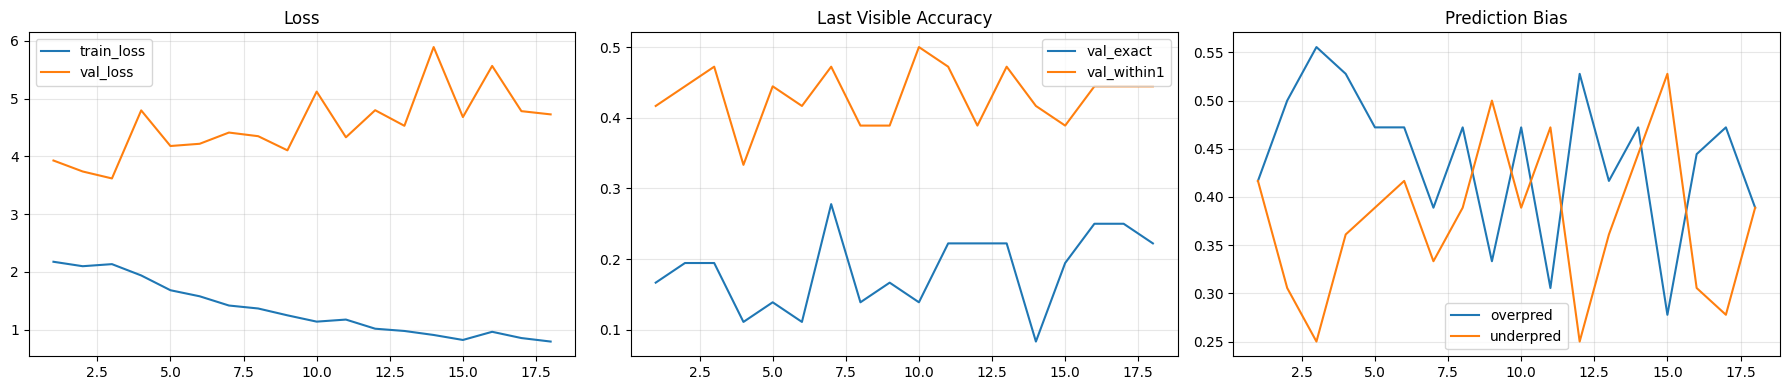

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train_loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['val_last_acc'], label='val_exact')
axes[1].plot(history_df['epoch'], history_df['val_last_within1_acc'], label='val_within1')
axes[1].set_title('Last Visible Accuracy')
axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['val_overprediction_rate'], label='overpred')
axes[2].plot(history_df['epoch'], history_df['val_underprediction_rate'], label='underpred')
axes[2].set_title('Prediction Bias')
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Clipping anatomico con el modelo refinado

Comparamos:

- `raw`
- `prev_range_clip` de la etapa anterior, si el archivo existe
- `last_pred_clip_refined`
- `oracle_clip`

In [11]:
prev_range_lookup = {}
if PREV_RANGE_TEST_PATH.exists():
    prev_range_df = pd.read_csv(PREV_RANGE_TEST_PATH)
    prev_range_lookup = prev_range_df.set_index('unique_sample_id').to_dict(orient='index')
    print('Se cargo referencia de visible-range estimator anterior.')
else:
    print('No se encontro archivo de range estimator anterior. Se omitira esa comparacion.')


def clip_mask_to_last_idx(mask_2d: np.ndarray, first_idx: int, last_idx: int) -> np.ndarray:
    first_idx = int(first_idx)
    last_idx = int(max(last_idx, first_idx))
    allowed_labels = canonical_labels[first_idx:last_idx + 1]
    allowed_ids = {label_to_class_id[label] for label in allowed_labels}
    out = np.zeros_like(mask_2d, dtype=np.int64)
    for class_id in allowed_ids:
        out[mask_2d == class_id] = class_id
    return out


test_gt_lookup = test_frame.set_index('unique_sample_id')[['first_visible_idx', 'last_visible_idx']].to_dict(orient='index')
last_pred_lookup = test_pred_df.set_index('unique_sample_id').to_dict(orient='index')

raw_pred_lookup = {}
oracle_clip_lookup = {}
last_pred_clip_lookup = {}
prev_range_clip_lookup = {}
target_lookup = {}
image_lookup = {}

for _, row in test_frame.iterrows():
    sample_id = row['unique_sample_id']
    raw_mask = raw_pred_lookup_all[sample_id]
    target_mask = target_lookup_all[sample_id]
    image_roi = image_crop_lookup[sample_id]

    gt_first = int(test_gt_lookup[sample_id]['first_visible_idx'])
    gt_last = int(test_gt_lookup[sample_id]['last_visible_idx'])
    pred_last = int(last_pred_lookup[sample_id]['last_pred_idx'])

    raw_pred_lookup[sample_id] = raw_mask
    oracle_clip_lookup[sample_id] = clip_mask_to_last_idx(raw_mask, gt_first, gt_last)
    last_pred_clip_lookup[sample_id] = clip_mask_to_last_idx(raw_mask, gt_first, pred_last)
    target_lookup[sample_id] = target_mask
    image_lookup[sample_id] = image_roi

    if sample_id in prev_range_lookup:
        prev_first = int(prev_range_lookup[sample_id]['first_pred_idx'])
        prev_last = int(prev_range_lookup[sample_id]['last_pred_idx'])
        prev_range_clip_lookup[sample_id] = clip_mask_to_last_idx(raw_mask, prev_first, prev_last)

print('Muestras de test preparadas para clipping:', len(raw_pred_lookup))

Se cargo referencia de visible-range estimator anterior.
Muestras de test preparadas para clipping: 45


## 11. Metricas de segmentacion comparadas

In [12]:
def metrics_from_prediction_lookup(pred_lookup: dict[str, np.ndarray], target_lookup_in: dict[str, np.ndarray]) -> tuple[pd.DataFrame, pd.DataFrame]:
    intersection = np.zeros(num_classes, dtype=np.float64)
    pred_area = np.zeros(num_classes, dtype=np.float64)
    target_area = np.zeros(num_classes, dtype=np.float64)
    total_valid_correct = 0.0
    total_valid_pixels = 0.0

    for sample_id, pred_mask in pred_lookup.items():
        target_mask = target_lookup_in[sample_id]
        valid = target_mask != IGNORE_INDEX
        total_valid_correct += float((pred_mask[valid] == target_mask[valid]).sum())
        total_valid_pixels += float(valid.sum())
        for class_id in range(num_classes):
            pred_class = pred_mask[valid] == class_id
            target_class = target_mask[valid] == class_id
            intersection[class_id] += np.logical_and(pred_class, target_class).sum()
            pred_area[class_id] += pred_class.sum()
            target_area[class_id] += target_class.sum()

    dice = (2.0 * intersection + 1e-6) / (pred_area + target_area + 1e-6)
    iou = (intersection + 1e-6) / (pred_area + target_area - intersection + 1e-6)
    per_class_df = pd.DataFrame({
        'class_id': np.arange(num_classes),
        'class_name': class_names,
        'pred_pixels': pred_area,
        'target_pixels': target_area,
        'dice': dice,
        'iou': iou,
    })
    per_class_df['region'] = per_class_df['class_name'].map(
        lambda x: 'background' if x == 'background' else ('thoracic' if x.startswith('T') else 'lumbar')
    )
    fg_df = per_class_df.loc[per_class_df['class_id'] > 0].copy()
    summary_df = pd.DataFrame([
        {'metric': 'pixel_accuracy', 'value': float((total_valid_correct + 1e-6) / (total_valid_pixels + 1e-6))},
        {'metric': 'macro_dice_fg', 'value': float(fg_df['dice'].mean())},
        {'metric': 'macro_iou_fg', 'value': float(fg_df['iou'].mean())},
        {'metric': 'macro_dice_thoracic', 'value': float(fg_df.loc[fg_df['region'] == 'thoracic', 'dice'].mean())},
        {'metric': 'macro_dice_lumbar', 'value': float(fg_df.loc[fg_df['region'] == 'lumbar', 'dice'].mean())},
    ])
    return summary_df, per_class_df


raw_summary_df, raw_per_class_df = metrics_from_prediction_lookup(raw_pred_lookup, target_lookup)
oracle_summary_df, oracle_per_class_df = metrics_from_prediction_lookup(oracle_clip_lookup, target_lookup)
last_summary_seg_df, last_per_class_df = metrics_from_prediction_lookup(last_pred_clip_lookup, target_lookup)

summary_compare_df = (
    raw_summary_df.rename(columns={'value': 'raw'})
    .merge(oracle_summary_df.rename(columns={'value': 'oracle_clip'}), on='metric')
    .merge(last_summary_seg_df.rename(columns={'value': 'last_pred_clip_refined'}), on='metric')
)
if prev_range_clip_lookup:
    prev_summary_df, prev_per_class_df = metrics_from_prediction_lookup(prev_range_clip_lookup, target_lookup)
    summary_compare_df = summary_compare_df.merge(prev_summary_df.rename(columns={'value': 'prev_range_clip'}), on='metric')
else:
    prev_per_class_df = pd.DataFrame()

display(summary_compare_df)

,metric,raw,oracle_clip,last_pred_clip_refined,prev_range_clip
0,pixel_accuracy,0.808721,0.825801,0.811669,0.808721
1,macro_dice_fg,0.296726,0.331591,0.292637,0.296726
2,macro_iou_fg,0.178742,0.205669,0.176133,0.178742
3,macro_dice_thoracic,0.277965,0.286478,0.279599,0.277965
4,macro_dice_lumbar,0.341754,0.439863,0.323929,0.341754


## 12. Analisis por muestra: extra labels y missing labels

Esta tabla nos dira si el nuevo clipping reduce la sobreprediccion sin destruir
la segmentacion util.

In [13]:
def present_labels_from_mask(mask_2d: np.ndarray) -> list[str]:
    ids = sorted([int(x) for x in np.unique(mask_2d) if int(x) > 0])
    return [class_names[i] for i in ids]


rows = []
for _, row in test_frame.iterrows():
    sample_id = row['unique_sample_id']
    target_mask = target_lookup[sample_id]
    raw_mask = raw_pred_lookup[sample_id]
    oracle_mask = oracle_clip_lookup[sample_id]
    last_mask = last_pred_clip_lookup[sample_id]

    gt_labels = present_labels_from_mask(np.where(target_mask == IGNORE_INDEX, 0, target_mask))
    raw_labels = present_labels_from_mask(raw_mask)
    oracle_labels = present_labels_from_mask(oracle_mask)
    last_labels = present_labels_from_mask(last_mask)

    record = {
        'unique_sample_id': sample_id,
        'split': row['split'],
        'image': row['image'],
        'gt_first_label': row['first_visible_label'],
        'gt_last_label': row['last_visible_label'],
        'last_pred_label': last_pred_lookup[sample_id]['last_pred_label'],
        'gt_labels': ', '.join(gt_labels),
        'raw_labels': ', '.join(raw_labels),
        'oracle_labels': ', '.join(oracle_labels),
        'last_pred_clip_labels': ', '.join(last_labels),
        'raw_extra_count': len(set(raw_labels) - set(gt_labels)),
        'oracle_extra_count': len(set(oracle_labels) - set(gt_labels)),
        'last_extra_count': len(set(last_labels) - set(gt_labels)),
        'raw_missing_count': len(set(gt_labels) - set(raw_labels)),
        'oracle_missing_count': len(set(oracle_labels) - set(gt_labels)),
        'last_missing_count': len(set(gt_labels) - set(last_labels)),
    }
    if sample_id in prev_range_clip_lookup:
        prev_labels = present_labels_from_mask(prev_range_clip_lookup[sample_id])
        record['prev_range_clip_labels'] = ', '.join(prev_labels)
        record['prev_extra_count'] = len(set(prev_labels) - set(gt_labels))
        record['prev_missing_count'] = len(set(gt_labels) - set(prev_labels))
    rows.append(record)

per_sample_compare_df = pd.DataFrame(rows)
per_sample_compare_df['last_extra_reduction_vs_raw'] = per_sample_compare_df['raw_extra_count'] - per_sample_compare_df['last_extra_count']
per_sample_compare_df['last_missing_change_vs_raw'] = per_sample_compare_df['last_missing_count'] - per_sample_compare_df['raw_missing_count']

summary_rows = [
    {'metric': 'mean_raw_extra_count', 'value': float(per_sample_compare_df['raw_extra_count'].mean())},
    {'metric': 'mean_oracle_extra_count', 'value': float(per_sample_compare_df['oracle_extra_count'].mean())},
    {'metric': 'mean_last_extra_count', 'value': float(per_sample_compare_df['last_extra_count'].mean())},
    {'metric': 'mean_raw_missing_count', 'value': float(per_sample_compare_df['raw_missing_count'].mean())},
    {'metric': 'mean_oracle_missing_count', 'value': float(per_sample_compare_df['oracle_missing_count'].mean())},
    {'metric': 'mean_last_missing_count', 'value': float(per_sample_compare_df['last_missing_count'].mean())},
    {'metric': 'samples_with_last_extra_reduction', 'value': int((per_sample_compare_df['last_extra_reduction_vs_raw'] > 0).sum())},
    {'metric': 'samples_with_last_missing_increase', 'value': int((per_sample_compare_df['last_missing_change_vs_raw'] > 0).sum())},
]
if 'prev_extra_count' in per_sample_compare_df.columns:
    summary_rows.extend([
        {'metric': 'mean_prev_extra_count', 'value': float(per_sample_compare_df['prev_extra_count'].mean())},
        {'metric': 'mean_prev_missing_count', 'value': float(per_sample_compare_df['prev_missing_count'].mean())},
    ])

presence_summary_df = pd.DataFrame(summary_rows)
display(presence_summary_df)
display(
    per_sample_compare_df.sort_values(
        ['last_extra_reduction_vs_raw', 'last_missing_change_vs_raw', 'raw_extra_count'],
        ascending=[False, True, False],
    ).head(20)
)

,metric,value
0,mean_raw_extra_count,3.022222
1,mean_oracle_extra_count,0.000000
2,mean_last_extra_count,1.822222
3,mean_raw_missing_count,0.066667
4,mean_oracle_missing_count,0.000000
5,mean_last_missing_count,0.400000
6,samples_with_last_extra_reduction,27.000000
7,samples_with_last_missing_increase,9.000000
8,mean_prev_extra_count,3.022222
9,mean_prev_missing_count,0.066667


,unique_sample_id,split,image,gt_first_label,gt_last_label,last_pred_label,gt_labels,raw_labels,oracle_labels,last_pred_clip_labels,...,oracle_extra_count,last_extra_count,raw_missing_count,oracle_missing_count,last_missing_count,prev_range_clip_labels,prev_extra_count,prev_missing_count,last_extra_reduction_vs_raw,last_missing_change_vs_raw
43,Scoliosis__S_180.jpg,Scoliosis,S_180.jpg,T1,T10,T10,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10",...,0,0,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",7,0,7,0
20,Scoliosis__S_28.jpg,Scoliosis,S_28.jpg,T1,T8,L1,"T1, T2, T3, T4, T5, T6, T7, T8","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,5,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",9,0,4,0
31,Scoliosis__S_89.jpg,Scoliosis,S_89.jpg,T1,T11,L1,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,2,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",6,0,4,0
21,Scoliosis__S_32.JPG,Scoliosis,S_32.JPG,T1,T12,L1,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,1,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",5,0,4,0
27,Scoliosis__S_67.jpg,Scoliosis,S_67.jpg,T1,T12,L1,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,1,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",5,0,4,0
40,Scoliosis__S_152.jpg,Scoliosis,S_152.jpg,T1,L1,L1,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,0,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",4,0,4,0
41,Scoliosis__S_174.jpg,Scoliosis,S_174.jpg,T1,L2,L1,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,0,0,0,1,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",3,0,3,1
44,Scoliosis__S_193.jpg,Scoliosis,S_193.jpg,T1,L2,L1,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,0,0,0,1,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",3,0,3,1
30,Scoliosis__S_84.jpg,Scoliosis,S_84.jpg,T1,T7,L3,"T1, T2, T3, T4, T5, T6, T7","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,8,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",10,0,2,0
22,Scoliosis__S_33.jpg,Scoliosis,S_33.jpg,T1,T12,L3,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, T12","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,0,3,0,0,0,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",5,0,2,0


## 13. Visualizacion cualitativa

Muestras seleccionadas: ['Scoliosis__S_180.jpg', 'Scoliosis__S_28.jpg', 'Scoliosis__S_89.jpg', 'Scoliosis__S_32.JPG', 'Scoliosis__S_67.jpg', 'Scoliosis__S_152.jpg', 'Scoliosis__S_174.jpg', 'Scoliosis__S_193.jpg']


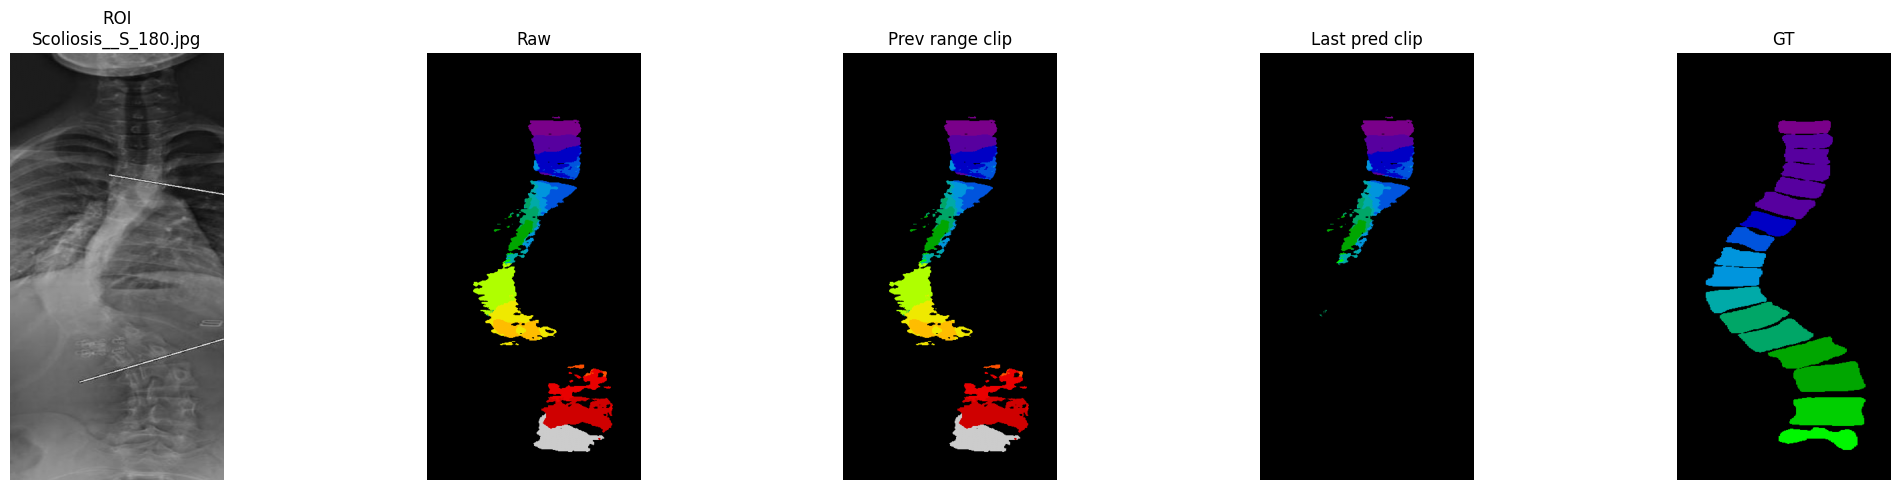

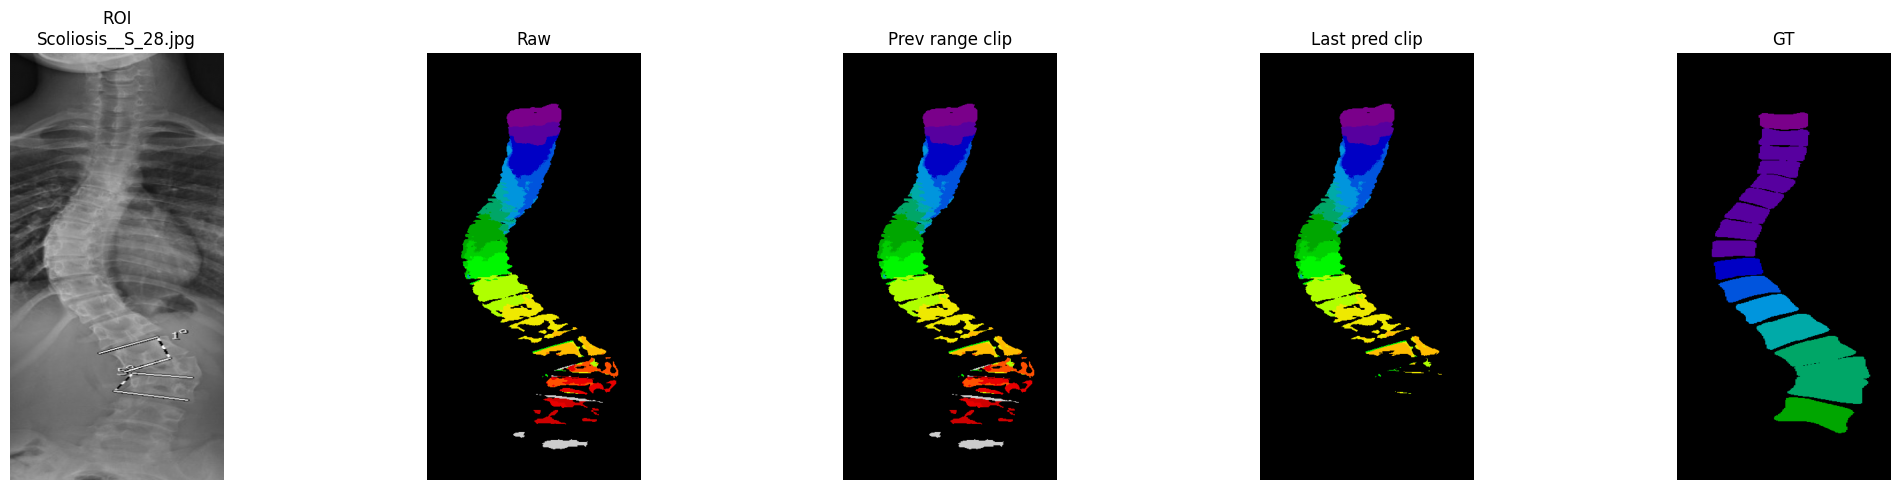

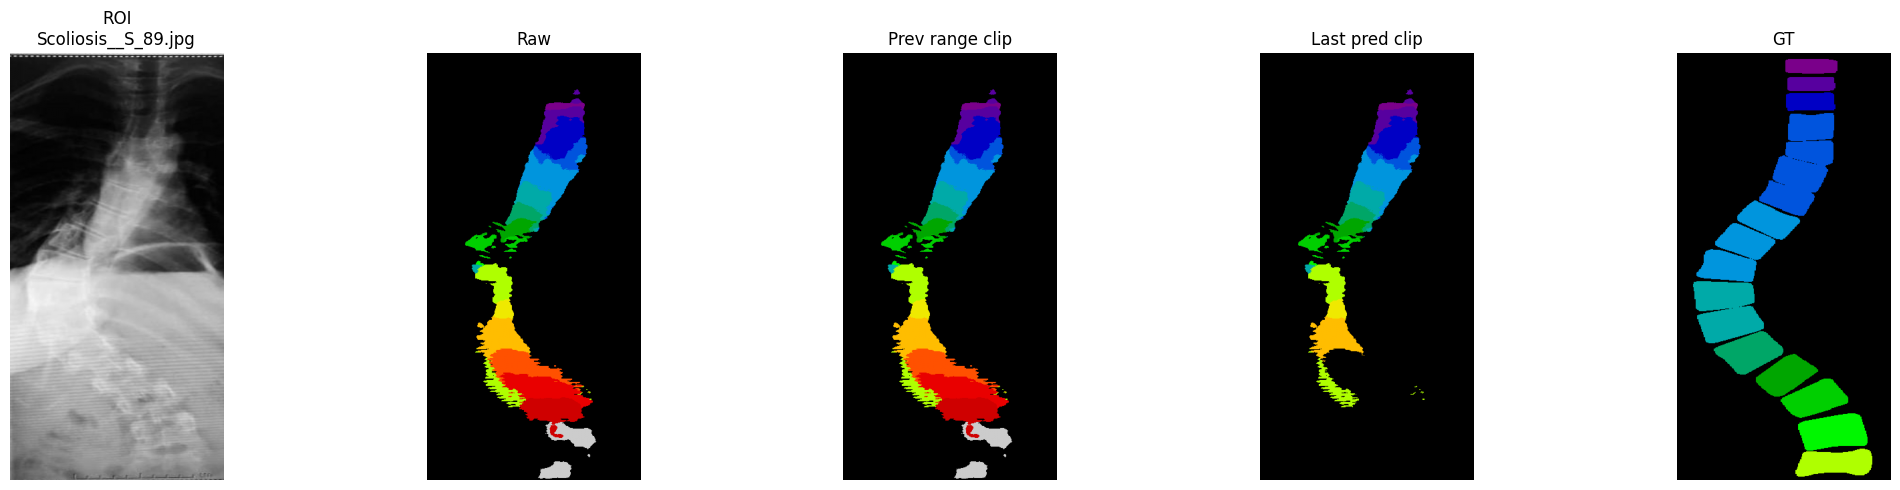

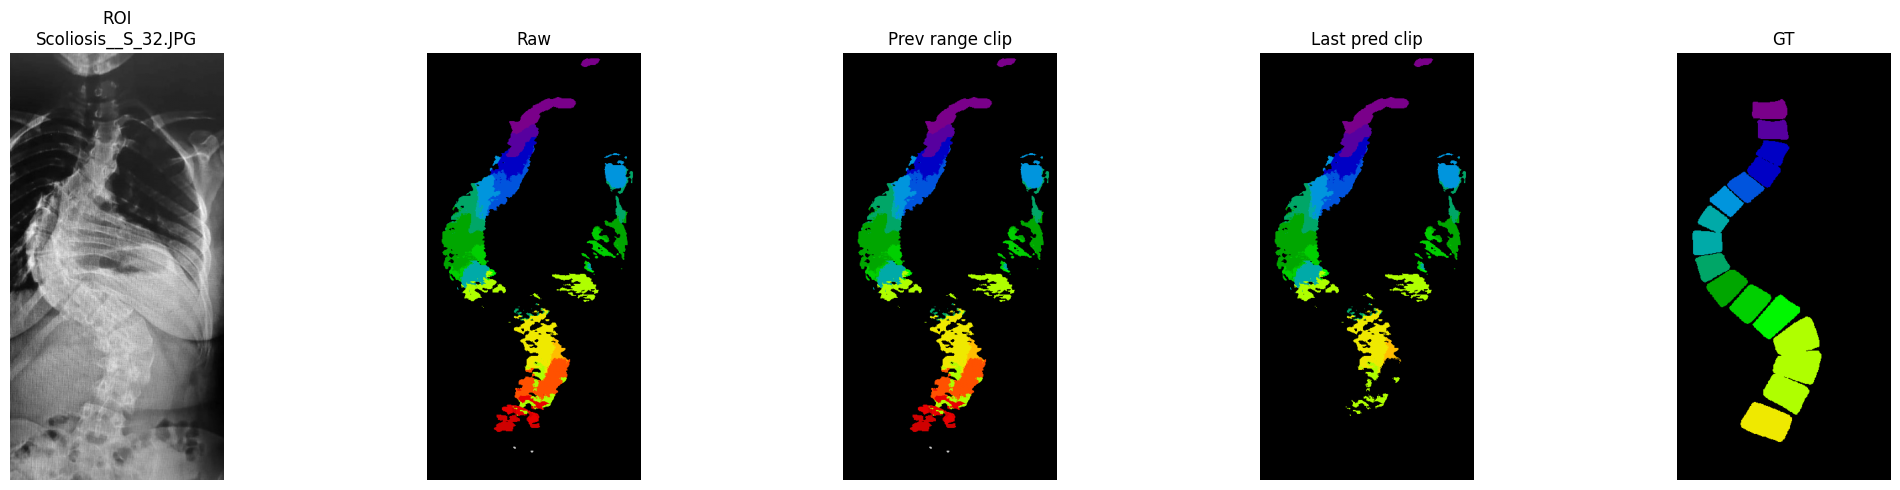

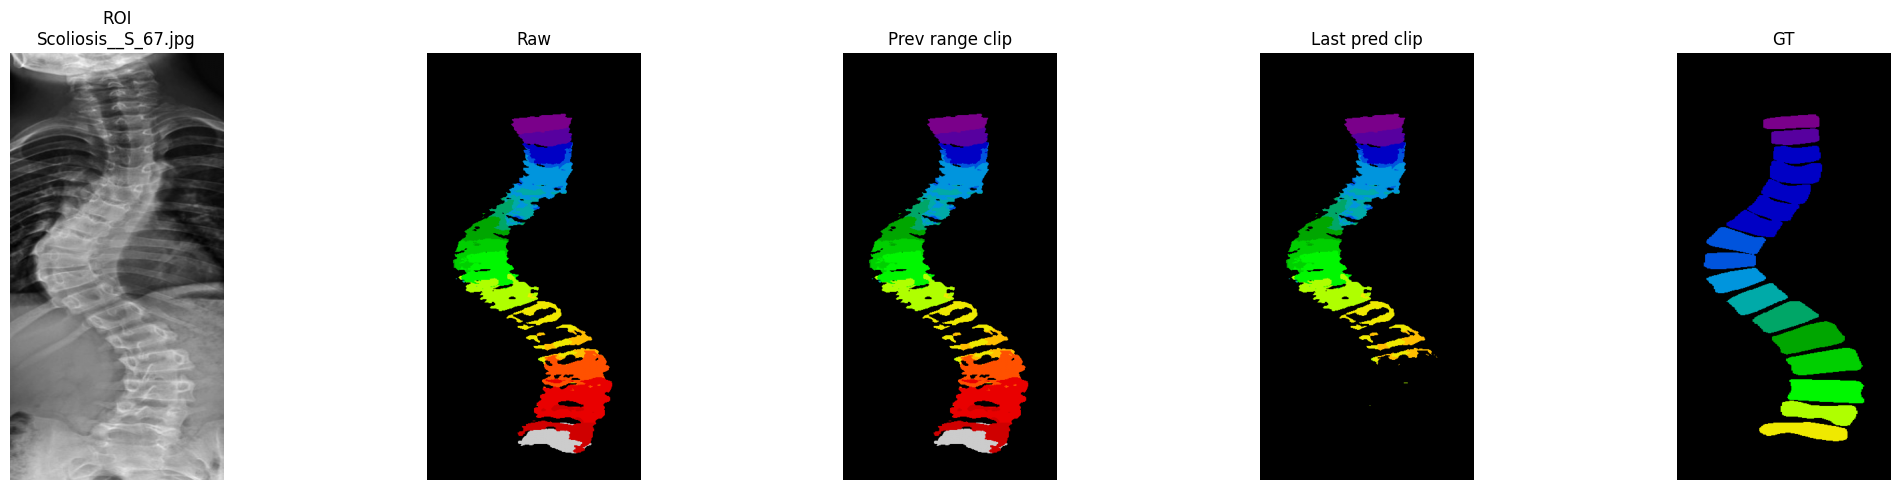

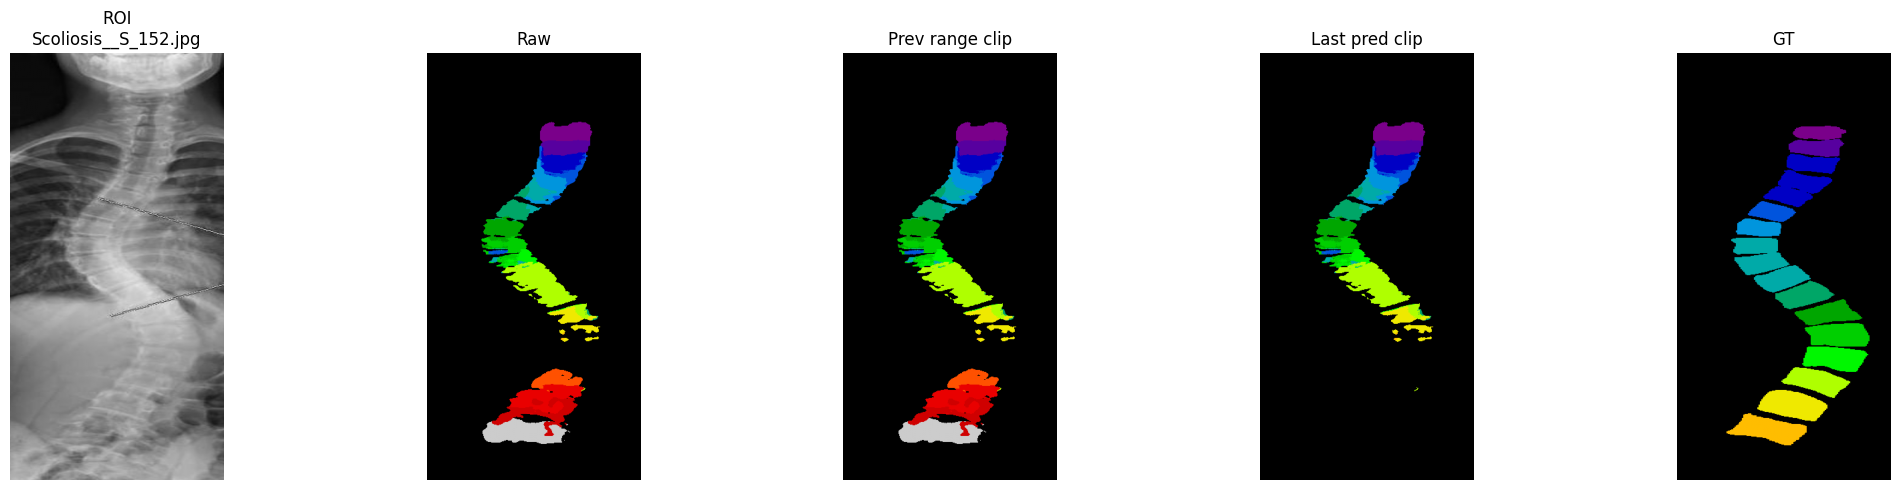

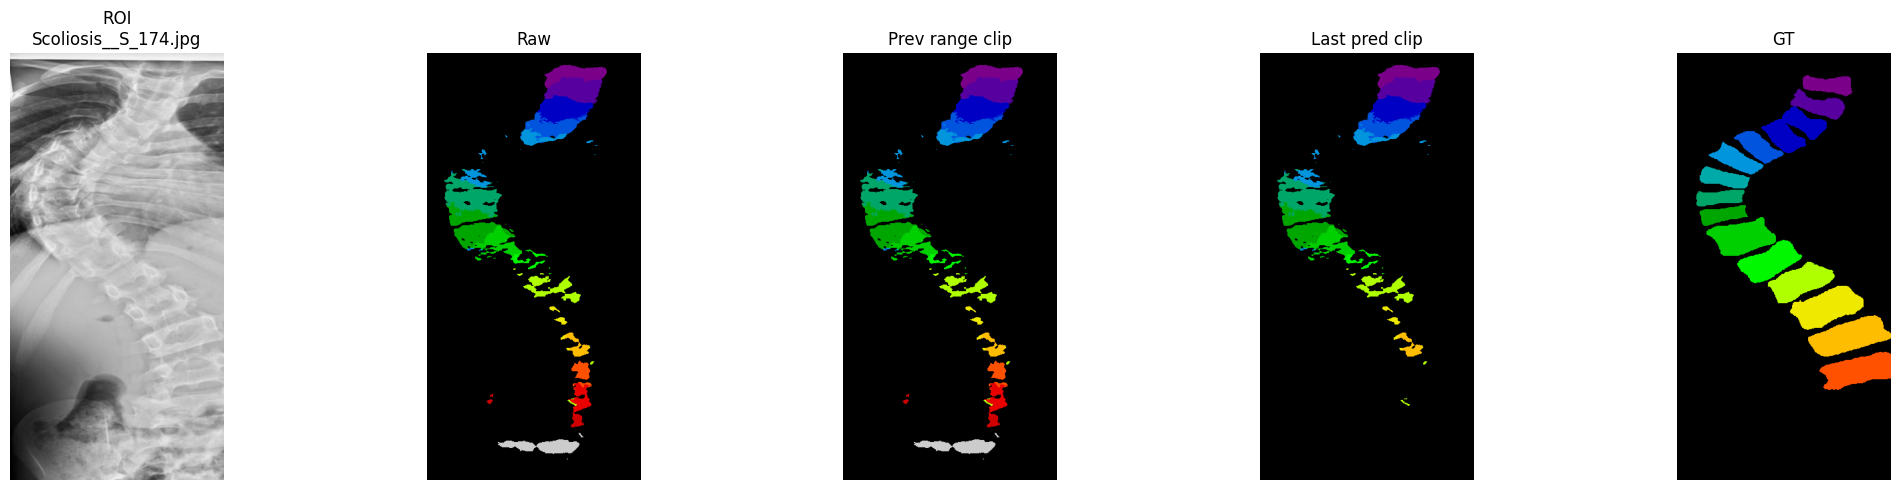

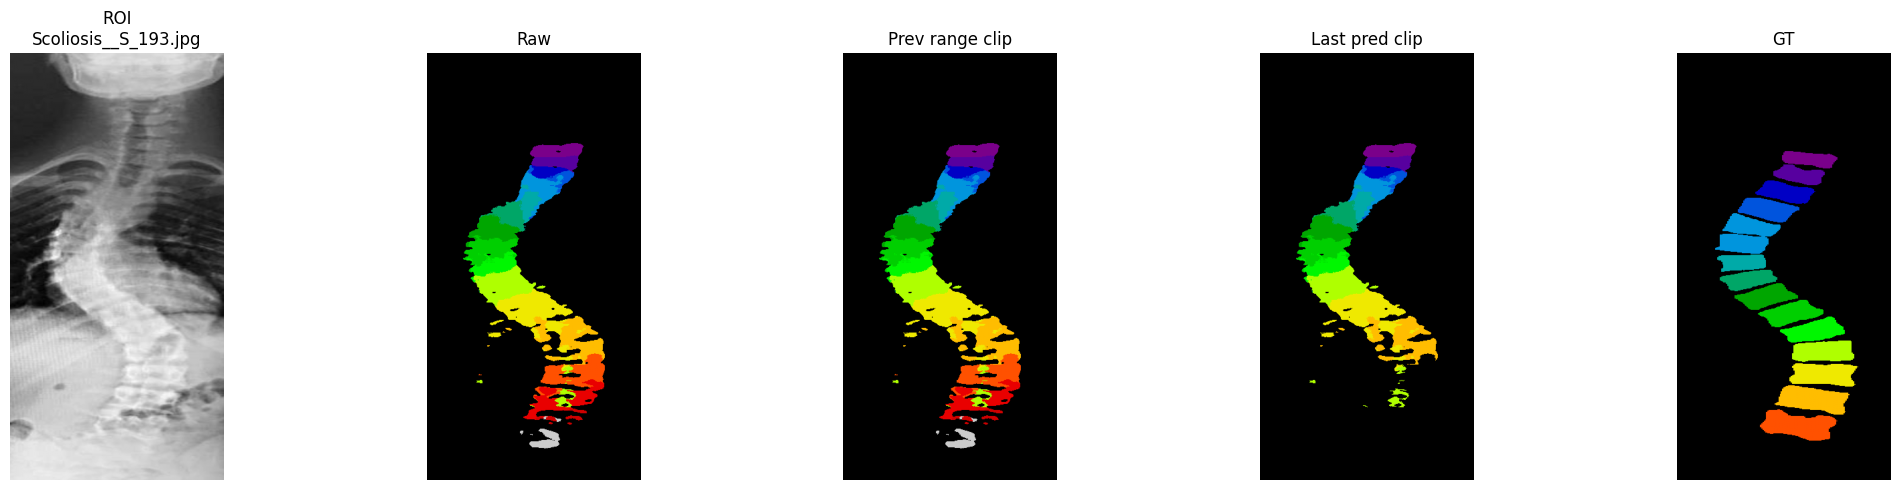

In [14]:
def show_sample(sample_id: str) -> None:
    image_gray = image_lookup[sample_id]
    raw_mask = raw_pred_lookup[sample_id]
    last_mask = last_pred_clip_lookup[sample_id]
    oracle_mask = oracle_clip_lookup[sample_id]
    target_mask = target_lookup[sample_id].copy()
    target_mask[target_mask == IGNORE_INDEX] = 0

    cols = 5 if sample_id in prev_range_clip_lookup else 4
    fig, axes = plt.subplots(1, cols, figsize=(4.4 * cols, 5))
    axes = np.atleast_1d(axes)
    axes[0].imshow(image_gray, cmap='gray')
    axes[0].set_title(f'ROI\n{sample_id}')
    axes[1].imshow(raw_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[1].set_title('Raw')
    offset = 2
    if sample_id in prev_range_clip_lookup:
        axes[2].imshow(prev_range_clip_lookup[sample_id], cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
        axes[2].set_title('Prev range clip')
        offset = 3
    axes[offset].imshow(last_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[offset].set_title('Last pred clip')
    axes[offset + 1].imshow(oracle_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[offset + 1].set_title('Oracle clip')
    axes[-1].imshow(target_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[-1].set_title('GT')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


sample_ids_to_show = per_sample_compare_df.sort_values(
    ['last_extra_reduction_vs_raw', 'last_missing_change_vs_raw', 'raw_extra_count'],
    ascending=[False, True, False],
)['unique_sample_id'].head(N_VIS_SAMPLES).tolist()

print('Muestras seleccionadas:', sample_ids_to_show)
for sample_id in sample_ids_to_show:
    show_sample(sample_id)

## 14. Exportacion de resultados

In [15]:
history_path = OUTPUT_DIR / 'last_visible_history.csv'
summary_path = OUTPUT_DIR / 'last_visible_summary.csv'
train_pred_path = OUTPUT_DIR / 'last_visible_train_predictions.csv'
val_pred_path = OUTPUT_DIR / 'last_visible_val_predictions.csv'
test_pred_path = OUTPUT_DIR / 'last_visible_test_predictions.csv'
compare_path = OUTPUT_DIR / 'last_visible_clipping_metric_comparison.csv'
raw_per_class_path = OUTPUT_DIR / 'last_visible_raw_per_class.csv'
oracle_per_class_path = OUTPUT_DIR / 'last_visible_oracle_per_class.csv'
last_per_class_path = OUTPUT_DIR / 'last_visible_pred_per_class.csv'
presence_path = OUTPUT_DIR / 'last_visible_presence_summary.csv'
per_sample_path = OUTPUT_DIR / 'last_visible_per_sample_compare.csv'

history_df.to_csv(history_path, index=False)
last_summary_df.to_csv(summary_path, index=False)
train_pred_df.to_csv(train_pred_path, index=False)
val_pred_df.to_csv(val_pred_path, index=False)
test_pred_df.to_csv(test_pred_path, index=False)
summary_compare_df.to_csv(compare_path, index=False)
raw_per_class_df.to_csv(raw_per_class_path, index=False)
oracle_per_class_df.to_csv(oracle_per_class_path, index=False)
last_per_class_df.to_csv(last_per_class_path, index=False)
presence_summary_df.to_csv(presence_path, index=False)
per_sample_compare_df.to_csv(per_sample_path, index=False)

experiment_summary_df = pd.DataFrame([
    {'metric': 'target_subset', 'value': TARGET_SUBSET},
    {'metric': 'test_samples', 'value': int(len(test_frame))},
    {'metric': 'last_test_exact_acc', 'value': float(test_metrics['last_acc'])},
    {'metric': 'last_test_within1_acc', 'value': float(test_metrics['last_within1_acc'])},
    {'metric': 'last_test_mae', 'value': float(test_metrics['last_mae'])},
    {'metric': 'last_test_overprediction_rate', 'value': float(test_metrics['overprediction_rate'])},
    {'metric': 'raw_macro_dice_fg', 'value': float(summary_compare_df.loc[summary_compare_df['metric'] == 'macro_dice_fg', 'raw'].iloc[0])},
    {'metric': 'oracle_macro_dice_fg', 'value': float(summary_compare_df.loc[summary_compare_df['metric'] == 'macro_dice_fg', 'oracle_clip'].iloc[0])},
    {'metric': 'last_pred_clip_refined_macro_dice_fg', 'value': float(summary_compare_df.loc[summary_compare_df['metric'] == 'macro_dice_fg', 'last_pred_clip_refined'].iloc[0])},
    {'metric': 'mean_raw_extra_count', 'value': float(per_sample_compare_df['raw_extra_count'].mean())},
    {'metric': 'mean_last_extra_count', 'value': float(per_sample_compare_df['last_extra_count'].mean())},
    {'metric': 'mean_raw_missing_count', 'value': float(per_sample_compare_df['raw_missing_count'].mean())},
    {'metric': 'mean_last_missing_count', 'value': float(per_sample_compare_df['last_missing_count'].mean())},
])
if BASELINE_SUMMARY_PATH is not None and BASELINE_SUMMARY_PATH.exists():
    experiment_summary_df = pd.concat([
        experiment_summary_df,
        pd.DataFrame([
            {
                'metric': 'delta_last_test_within1_acc_vs_baseline',
                'value': float(test_metrics['last_within1_acc']) - float(baseline_summary_wide.get('last_test_within1_acc', np.nan)),
            },
            {
                'metric': 'delta_last_test_overprediction_rate_vs_baseline',
                'value': float(test_metrics['overprediction_rate']) - float(baseline_summary_wide.get('last_test_overprediction_rate', np.nan)),
            },
            {
                'metric': 'delta_last_pred_clip_macro_dice_fg_vs_baseline',
                'value': float(summary_compare_df.loc[summary_compare_df['metric'] == 'macro_dice_fg', 'last_pred_clip_refined'].iloc[0]) - float(baseline_summary_wide.get('last_pred_clip_macro_dice_fg', np.nan)),
            },
        ])
    ], ignore_index=True)

experiment_path = OUTPUT_DIR / 'last_visible_refined_experiment_summary.csv'
baseline_compare_path = OUTPUT_DIR / 'last_visible_refined_vs_baseline_compare.csv'
sampler_weights_path = OUTPUT_DIR / 'last_visible_refined_train_sampler_weights.csv'
hard_case_eval_path = OUTPUT_DIR / 'last_visible_refined_hard_case_eval.csv'
experiment_summary_df.to_csv(experiment_path, index=False)
baseline_compare_df.to_csv(baseline_compare_path, index=False)
train_frame[
    [
        'unique_sample_id', 'split', 'image', 'last_visible_label',
        'last_visible_training_weight', 'curriculum_boost', 'sampler_weight'
    ]
].to_csv(sampler_weights_path, index=False)
if not hard_case_eval_df.empty:
    hard_case_eval_df.to_csv(hard_case_eval_path, index=False)

display(experiment_summary_df)
display(baseline_compare_df)
if not hard_case_eval_df.empty:
    display(hard_case_eval_df)
print('Guardado:', history_path)
print('Guardado:', summary_path)
print('Guardado:', train_pred_path)
print('Guardado:', val_pred_path)
print('Guardado:', test_pred_path)
print('Guardado:', compare_path)
print('Guardado:', raw_per_class_path)
print('Guardado:', oracle_per_class_path)
print('Guardado:', last_per_class_path)
print('Guardado:', presence_path)
print('Guardado:', per_sample_path)
print('Guardado:', experiment_path)
print('Guardado:', baseline_compare_path)
print('Guardado:', sampler_weights_path)
if not hard_case_eval_df.empty:
    print('Guardado:', hard_case_eval_path)

,metric,value
0,target_subset,partial
1,test_samples,45
2,last_test_exact_acc,0.288889
3,last_test_within1_acc,0.555556
4,last_test_mae,2.222222
5,last_test_overprediction_rate,0.466667
6,raw_macro_dice_fg,0.296726
7,oracle_macro_dice_fg,0.331591
8,last_pred_clip_refined_macro_dice_fg,0.292637
9,mean_raw_extra_count,3.022222


,metric,baseline,refined,delta_refined_minus_baseline
0,last_test_exact_acc,0.333333,0.288889,-0.044444
1,last_test_within1_acc,0.511111,0.555556,0.044444
2,last_test_mae,2.400000,2.222222,-0.177778
3,last_test_overprediction_rate,0.488889,0.466667,-0.022222


,metric,value
0,hard_case_samples,45.000000
1,hard_case_exact_acc,0.288889
2,hard_case_within1_acc,0.555556
3,hard_case_mae,2.222222
4,hard_case_overprediction_rate,0.466667


Guardado: /content/drive/MyDrive/DataRadriografias/analysis_outputs/last_visible_estimator_thoracolumbar_refined_explained/last_visible_history.csv
Guardado: /content/drive/MyDrive/DataRadriografias/analysis_outputs/last_visible_estimator_thoracolumbar_refined_explained/last_visible_summary.csv
Guardado: /content/drive/MyDrive/DataRadriografias/analysis_outputs/last_visible_estimator_thoracolumbar_refined_explained/last_visible_train_predictions.csv
Guardado: /content/drive/MyDrive/DataRadriografias/analysis_outputs/last_visible_estimator_thoracolumbar_refined_explained/last_visible_val_predictions.csv
Guardado: /content/drive/MyDrive/DataRadriografias/analysis_outputs/last_visible_estimator_thoracolumbar_refined_explained/last_visible_test_predictions.csv
Guardado: /content/drive/MyDrive/DataRadriografias/analysis_outputs/last_visible_estimator_thoracolumbar_refined_explained/last_visible_clipping_metric_comparison.csv
Guardado: /content/drive/MyDrive/DataRadriografias/analysis_output